## **011963 ML for Civil and Environmental Engineering**

#### **04. Exploratory Data Analysis (EDA) & Data Preprocessing**
#### **Made by SSJin (2026.03.23)**
#### Sejong University, Dept. of Civil & Environmental Engineering

---

> **Convention:**
> - <font color='blue'>**Blue = Example**</font>: Worked examples with complete code.
> - <font color='red'>**Red = Exercise**</font>: Fill in the blanks (`________`).
> - Answer keys are at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

---
#### **0 - What is Exploratory Data Analysis (EDA)?**

EDA is the process of **investigating a dataset** to discover patterns, spot anomalies, test hypotheses, and check assumptions — primarily through **visual** and **statistical** methods.

| Phase | Purpose | Techniques |
|-------|---------|------------|
| **Understand** | Know your data's shape, types, missing values | `.shape`, `.info()`, `.describe()` |
| **Clean** | Handle missing values, duplicates, outliers | `.dropna()`, `.fillna()`, IQR method |
| **Explore** | Find patterns and relationships | Histograms, scatter plots, correlation |
| **Transform** | Prepare data for modeling | Log transform, encoding, scaling |

#### **Why is EDA Important?**

- **80% of ML work** is data preparation and EDA
- Garbage in → Garbage out: model quality depends on data quality
- EDA reveals **which features matter** and **how to preprocess** them

---
#### **1 - EDA Cheat Sheet**

| Analysis Type | # Variables | Techniques |
|---------------|-------------|------------|
| **Univariate** | 1 | Histogram, boxplot, describe(), value_counts() |
| **Bivariate** | 2 | Scatter plot, correlation, jointplot |
| **Multivariate** | 3+ | Pairplot, heatmap, 3D scatter |

---
#### **2 - Dataset: Concrete Compressive Strength**

We'll use a **CEE-relevant dataset**: predicting concrete compressive strength from its mix components.

| Feature | Description | Unit |
|---------|-------------|------|
| Cement | Cement content | kg/m³ |
| Slag | Blast Furnace Slag | kg/m³ |
| Ash | Fly Ash | kg/m³ |
| Water | Water content | kg/m³ |
| Superplasticizer | Superplasticizer additive | kg/m³ |
| Coarse_Agg | Coarse Aggregate | kg/m³ |
| Fine_Agg | Fine Aggregate | kg/m³ |
| Age | Curing age | days |
| **Strength** | Compressive strength (**target**) | MPa |

##### **Step 1: Load Data**

<font color='blue'>**Example) Load the concrete dataset and inspect basic info**</font>

In [2]:
# Generate a synthetic concrete dataset (based on UCI Concrete Strength data distributions)
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'Cement': np.random.uniform(100, 550, n),
    'Slag': np.random.uniform(0, 360, n),
    'Ash': np.random.uniform(0, 200, n),
    'Water': np.random.uniform(120, 250, n),
    'Superplasticizer': np.random.uniform(0, 32, n),
    'Coarse_Agg': np.random.uniform(800, 1150, n),
    'Fine_Agg': np.random.uniform(590, 990, n),
    'Age': np.random.choice([1, 3, 7, 14, 28, 56, 90, 180, 365], n),
})
# Target: simplified strength model with noise
df['Strength'] = (
    0.08*df['Cement'] + 0.02*df['Slag'] - 0.05*df['Water'] 
    + 0.1*df['Superplasticizer'] + 2*np.log(df['Age']+1)
    + np.random.normal(0, 5, n)
)
df['Strength'] = df['Strength'].clip(lower=2)

# Inject some missing values for practice
for col in ['Slag', 'Ash', 'Superplasticizer']:
    mask = np.random.random(n) < 0.05
    df.loc[mask, col] = np.nan

# Inject some duplicates
df = pd.concat([df, df.sample(10, random_state=0)], ignore_index=True)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (510, 9)


,Cement,Slag,Ash,Water,Superplasticizer,Coarse_Agg,Fine_Agg,Age,Strength
0,268.543053,251.338217,37.026586,187.480632,8.374582,1089.631623,859.081198,180,24.913757
1,527.821438,192.994692,108.380189,182.293644,7.903322,1067.584728,908.672559,365,54.792198
2,429.397274,111.429942,174.589167,123.333469,29.000147,1000.735133,690.187160,7,41.589152
3,369.396318,292.966207,146.444977,164.362218,7.985478,1134.616500,839.949640,7,26.900953
4,170.208388,246.503222,161.312230,169.425430,8.702391,870.166080,818.698393,14,21.152828


##### **Step 2: Understanding Data**

<font color='blue'>**Example) Inspect data types, shape, and summary statistics**</font>

In [3]:
print('=== Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print()
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Info ===')
df.info()

=== Shape ===
Rows: 510, Columns: 9

=== Data Types ===
Cement              float64
Slag                float64
Ash                 float64
Water               float64
Superplasticizer    float64
Coarse_Agg          float64
Fine_Agg            float64
Age                   int32
Strength            float64
dtype: object

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cement            510 non-null    float64
 1   Slag              492 non-null    float64
 2   Ash               481 non-null    float64
 3   Water             510 non-null    float64
 4   Superplasticizer  479 non-null    float64
 5   Coarse_Agg        510 non-null    float64
 6   Fine_Agg          510 non-null    float64
 7   Age               510 non-null    int32  
 8   Strength          510 non-null    float64
dtypes: float64(8), int32(1)
memory usage: 

In [4]:
print('=== Summary Statistics ===')
df.describe().T

=== Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
Cement,510.0,324.082948,134.499853,102.277713,207.153384,330.272978,439.884583,546.834158
Slag,492.0,173.305036,102.969066,1.667528,81.947992,170.285145,262.389037,359.898362
Ash,481.0,104.383262,59.777467,0.987996,48.409003,110.171474,156.477097,199.882745
Water,510.0,184.569416,37.234207,120.418374,151.756587,186.155874,215.754241,249.785176
Superplasticizer,479.0,16.016598,9.223791,0.050083,8.511254,16.166617,23.962443,31.854001
Coarse_Agg,510.0,977.376273,103.734179,800.004072,891.441094,976.378921,1069.808583,1149.237299
Fine_Agg,510.0,788.711491,112.630061,590.796854,690.229674,795.987802,879.306874,989.557045
Age,510.0,86.437255,112.319862,1.000000,7.000000,28.000000,90.000000,365.000000
Strength,510.0,28.317655,12.579425,2.000000,18.847137,28.166501,37.799705,60.532600


<font color='red'>**Exercise 2.1) Check for missing values in each column and calculate the percentage.**</font>

In [5]:
# Count missing values per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Count': missing_count, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])

                  Count  Percentage
Slag                 18    3.529412
Ash                  29    5.686275
Superplasticizer     31    6.078431


<font color='red'>**Exercise 2.2) Check for and remove duplicate rows.**</font>

In [6]:
# Count duplicates
n_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {n_duplicates}')

# Remove duplicates
df = df.drop_duplicates(subset=None, keep='first')
print(f'Shape after removing duplicates: {df.shape}')

Number of duplicate rows: 10
Shape after removing duplicates: (500, 9)


---
#### **3 - Univariate Analysis (Single Variable)**

##### **3.1 Histograms and KDE**

<font color='blue'>**Example) Distribution of each feature using histograms + KDE**</font>

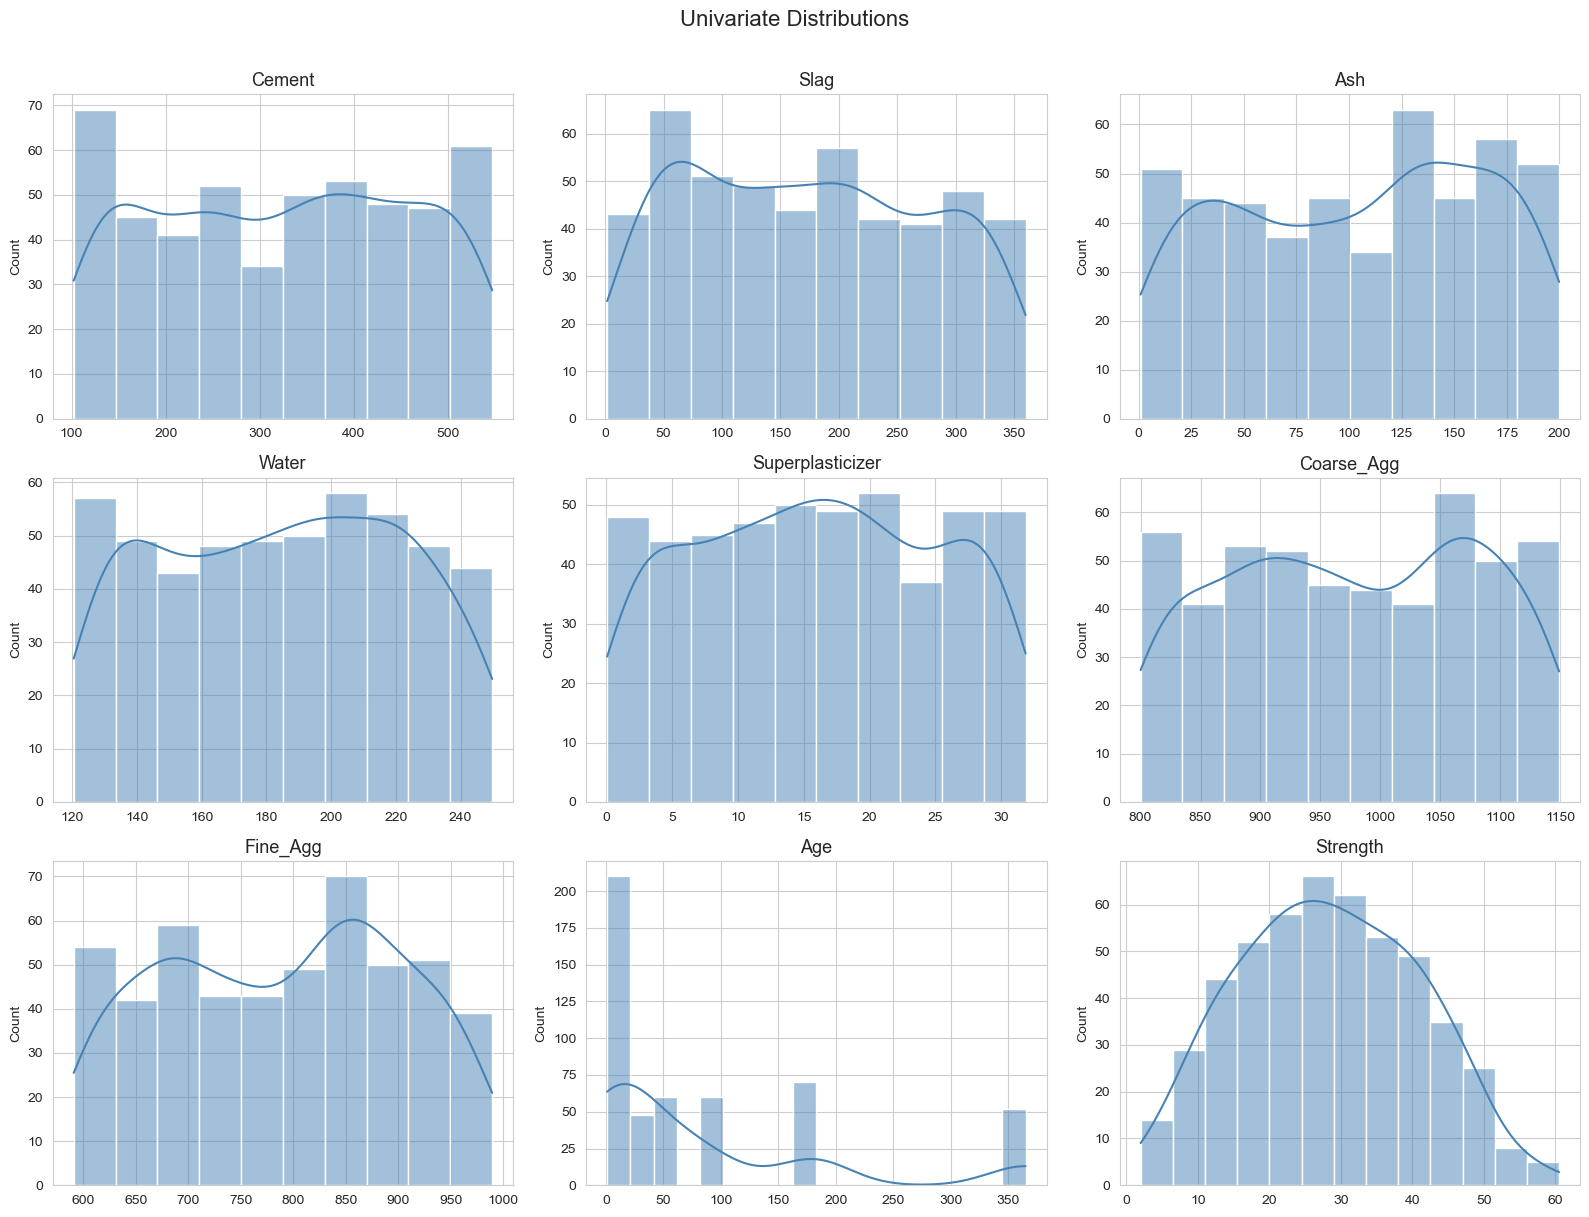

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n_cols_plot = 3
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 4*n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_xlabel('')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

##### **3.2 Skewness**

<font color='blue'>**Example) Check skewness of each numerical column**</font>

In [8]:
print(f'{"Column":<20} {"Skewness":>10}')
print('-' * 32)
for col in num_cols:
    skew = df[col].skew()
    flag = ' ⚠️' if abs(skew) > 1 else ''
    print(f'{col:<20} {skew:>10.2f}{flag}')

Column                 Skewness
--------------------------------
Cement                    -0.03
Slag                       0.10
Ash                       -0.12
Water                     -0.02
Superplasticizer           0.00
Coarse_Agg                -0.05
Fine_Agg                  -0.06
Age                        1.54 ⚠️
Strength                   0.08


##### **3.3 Box Plots (Outlier Detection)**

<font color='blue'>**Example) Box plots for all numerical features**</font>

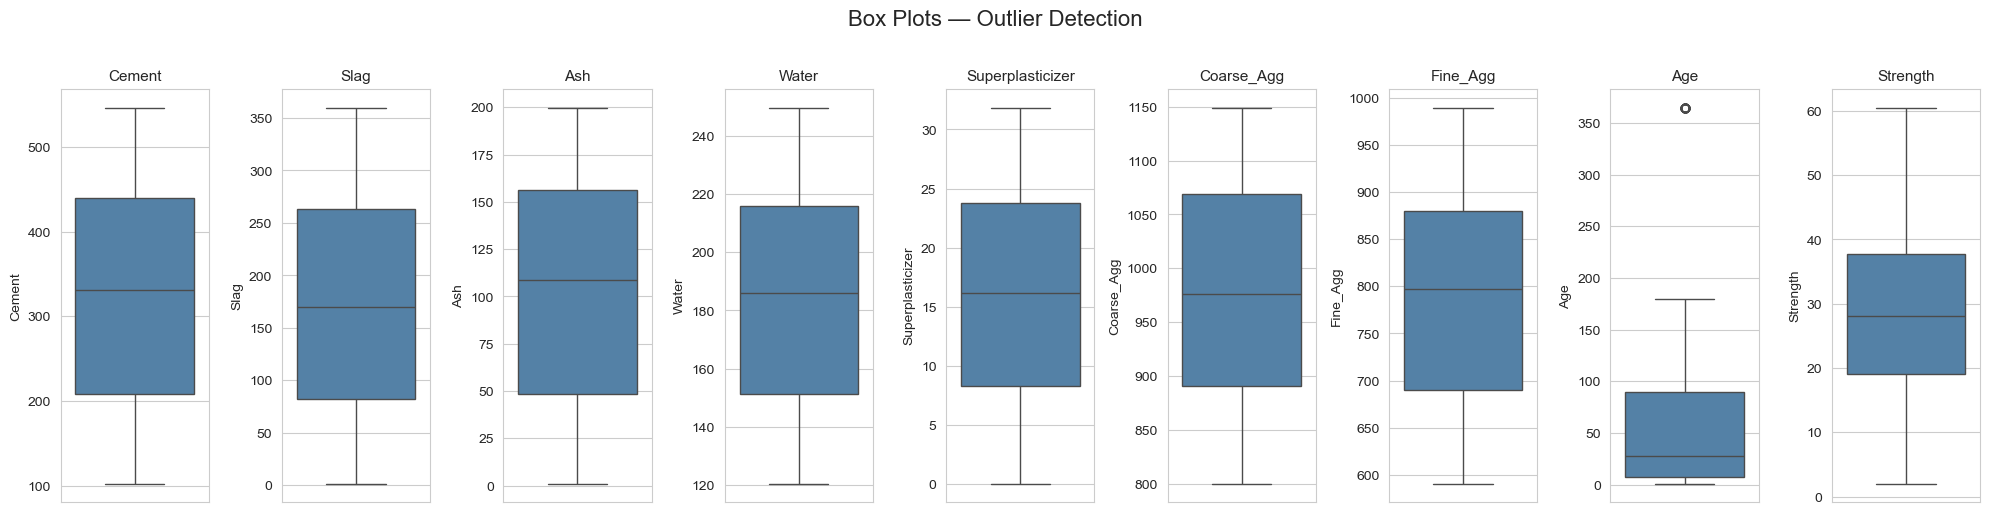

In [9]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)
plt.suptitle('Box Plots — Outlier Detection', fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

##### **3.4 CDF (Cumulative Distribution Function)**

<font color='red'>**Exercise 3.1) Plot the empirical CDF of the `Strength` column.**</font>

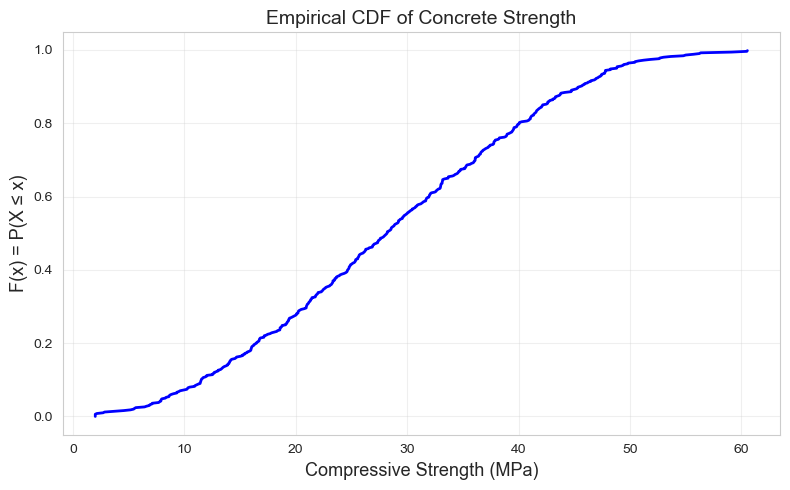

In [10]:
strength_sorted = np.sort(df['Strength'].dropna())
cdf_y = np.arange(len(strength_sorted)) / len(strength_sorted)

plt.figure(figsize=(8, 5))
plt.plot(strength_sorted, cdf_y, 'b-', linewidth=2)
plt.xlabel('Compressive Strength (MPa)', fontsize=13)
plt.ylabel('F(x) = P(X ≤ x)', fontsize=13)
plt.title('Empirical CDF of Concrete Strength', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
#### **4 - Bivariate Analysis (Two Variables)**

##### **4.1 Scatter Plots**

<font color='blue'>**Example) Scatter plot: Cement vs Strength**</font>

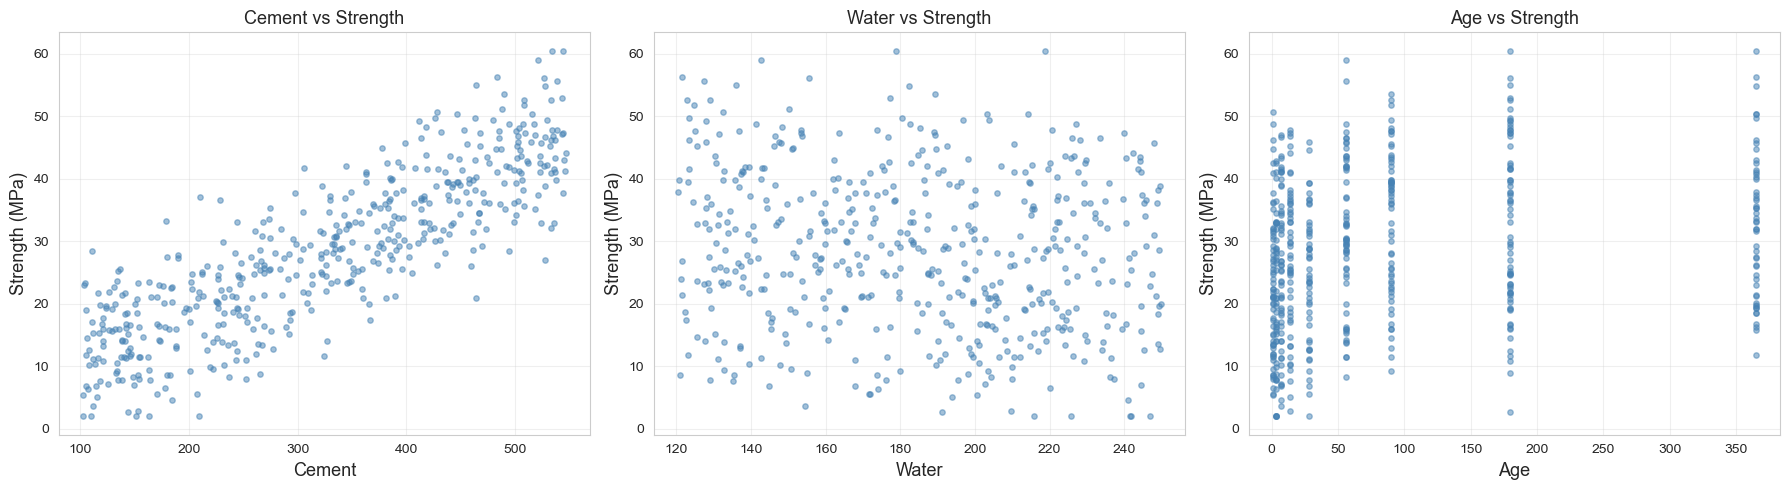

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Cement', 'Water', 'Age']):
    ax.scatter(df[col], df['Strength'], s=15, alpha=0.5, color='steelblue')
    ax.set_xlabel(col, fontsize=13); ax.set_ylabel('Strength (MPa)', fontsize=13)
    ax.set_title(f'{col} vs Strength', fontsize=13); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##### **4.2 Joint Plot**

<font color='blue'>**Example) Joint distribution of Cement and Strength**</font>

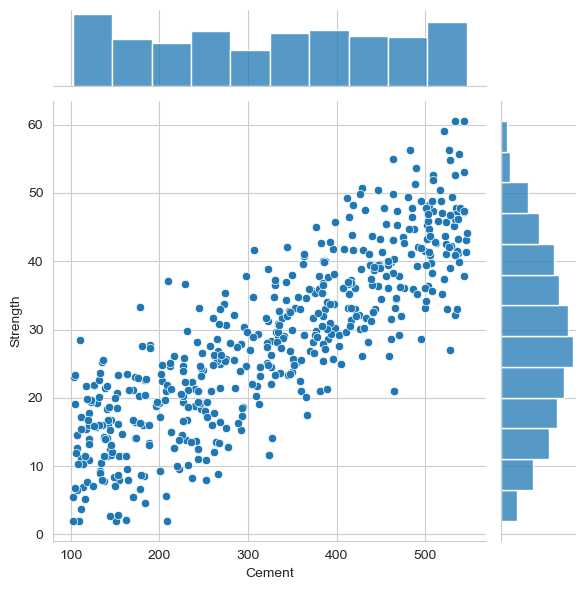

In [12]:
sns.jointplot(x='Cement', y='Strength', data=df, kind='scatter', height=6)
plt.show()

<font color='blue'>**Example) KDE joint plot for Age and Strength**</font>

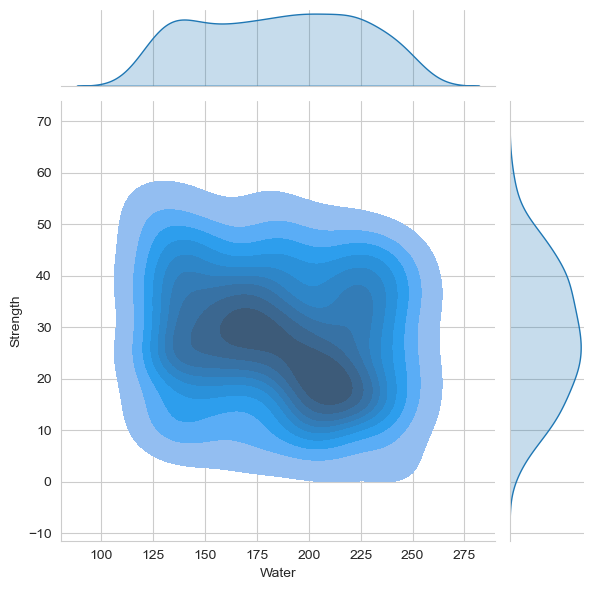

In [13]:
sns.jointplot(x='Water', y='Strength', data=df, kind='kde', fill=True, height=6)
plt.show()

<font color='red'>**Exercise 4.1) Create a violin plot comparing Strength across different Age groups.**</font>

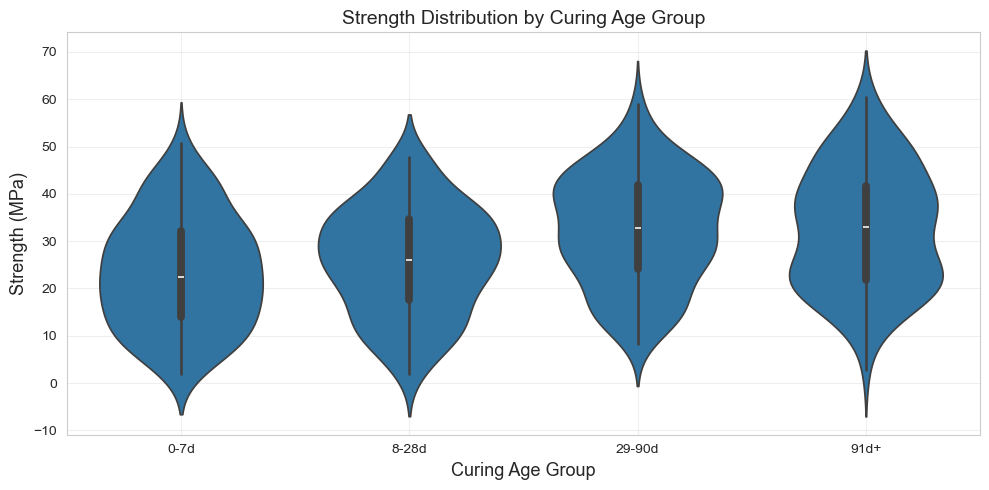

In [14]:
# Create Age groups for visualization
df['Age_group'] = pd.cut(df['Age'], bins=[0, 7, 28, 90, 400], labels=['0-7d', '8-28d', '29-90d', '91d+'])

plt.figure(figsize=(10, 5))
sns.violinplot(x='Age_group', y='Strength', data=df)
plt.title('Strength Distribution by Curing Age Group', fontsize=14)
plt.xlabel('Curing Age Group', fontsize=13)
plt.ylabel('Strength (MPa)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
#### **5 - Multivariate Analysis (3+ Variables)**

##### **5.1 Pair Plot**

<font color='blue'>**Example) Pair plot of key features**</font>

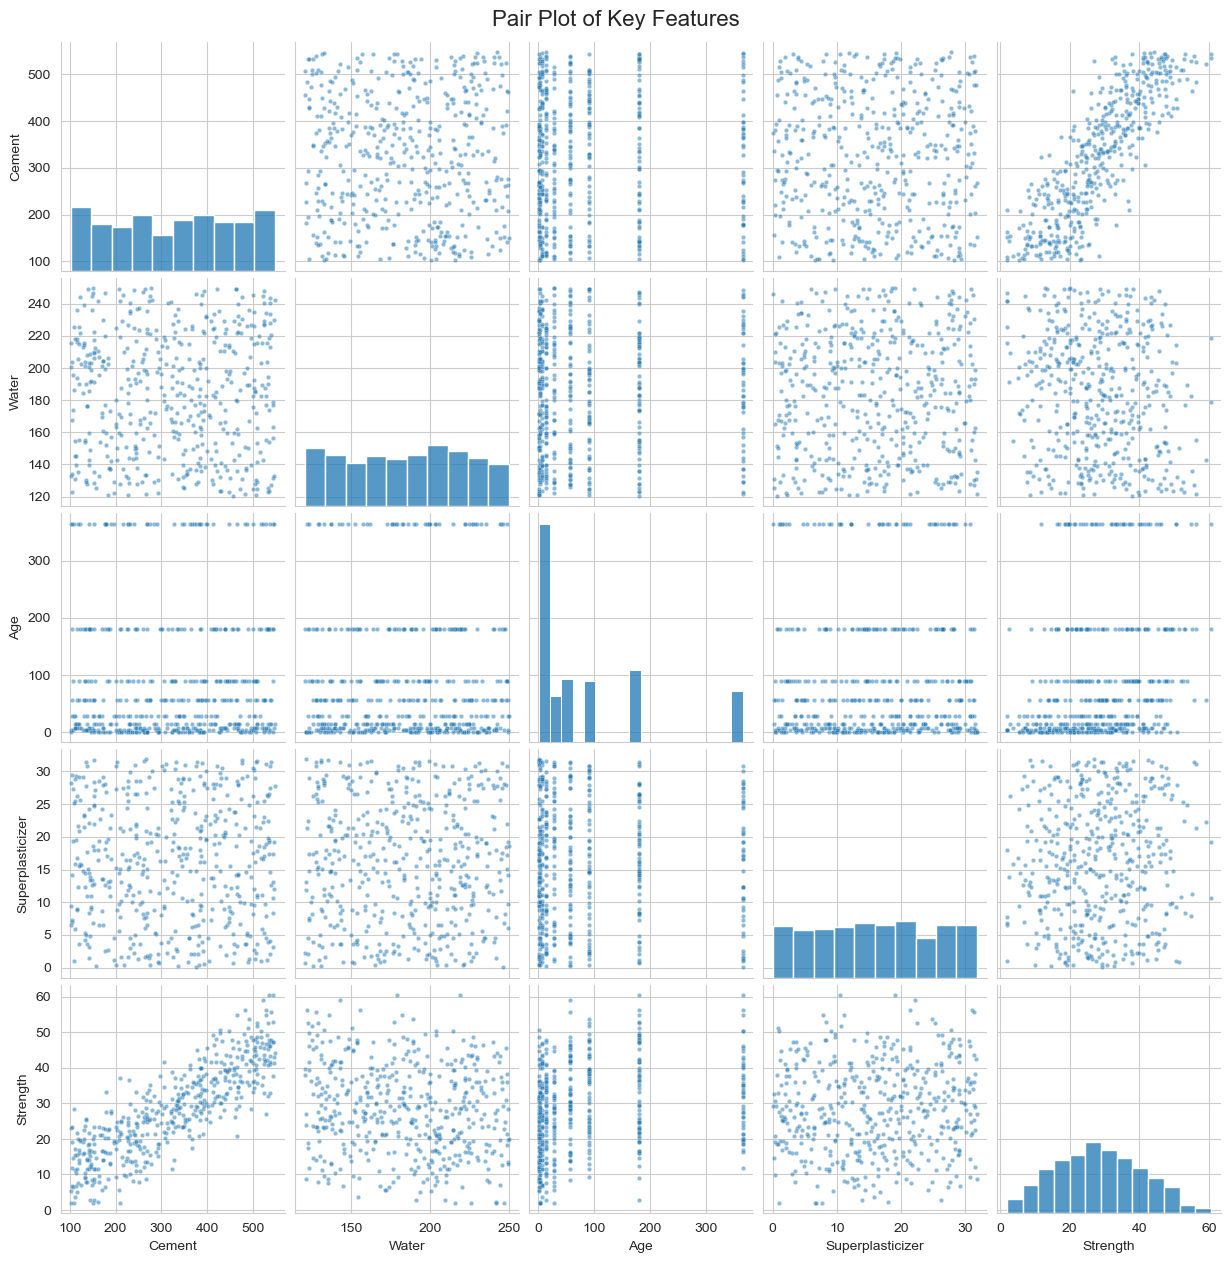

In [15]:
key_features = ['Cement', 'Water', 'Age', 'Superplasticizer', 'Strength']
sns.pairplot(df[key_features].dropna(), height=2.5, plot_kws={'s': 10, 'alpha': 0.5})
plt.suptitle('Pair Plot of Key Features', fontsize=16, y=1.01)
plt.show()

##### **5.2 Correlation Heatmap**

<font color='red'>**Exercise 5.1) Create a correlation heatmap for all numerical columns.**</font>

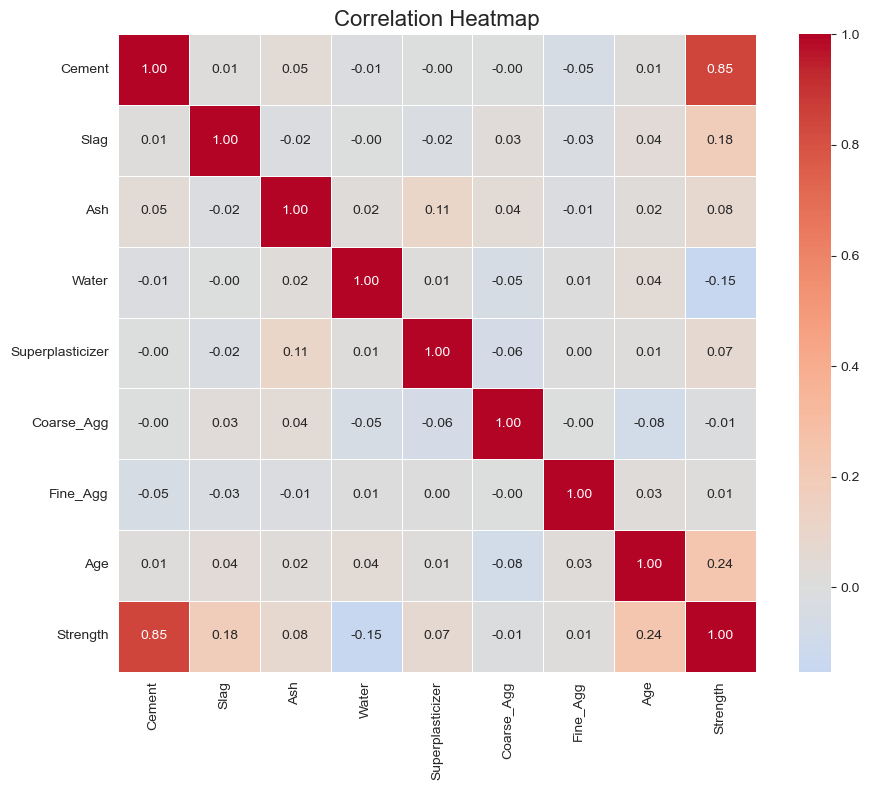


Correlation with Strength:
Cement              0.847496
Age                 0.239165
Slag                0.175367
Ash                 0.075017
Superplasticizer    0.070334
Fine_Agg            0.011325
Coarse_Agg         -0.009944
Water              -0.152949
Name: Strength, dtype: float64


In [16]:
plt.figure(figsize=(10, 8))

corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout(); plt.show()

# Which feature has the highest correlation with Strength?
print('\nCorrelation with Strength:')
print(corr_matrix['Strength'].drop('Strength').sort_values(ascending=False))

##### **5.3 3D Scatter Plot**

<font color='blue'>**Example) 3D scatter: Cement × Water × Strength**</font>

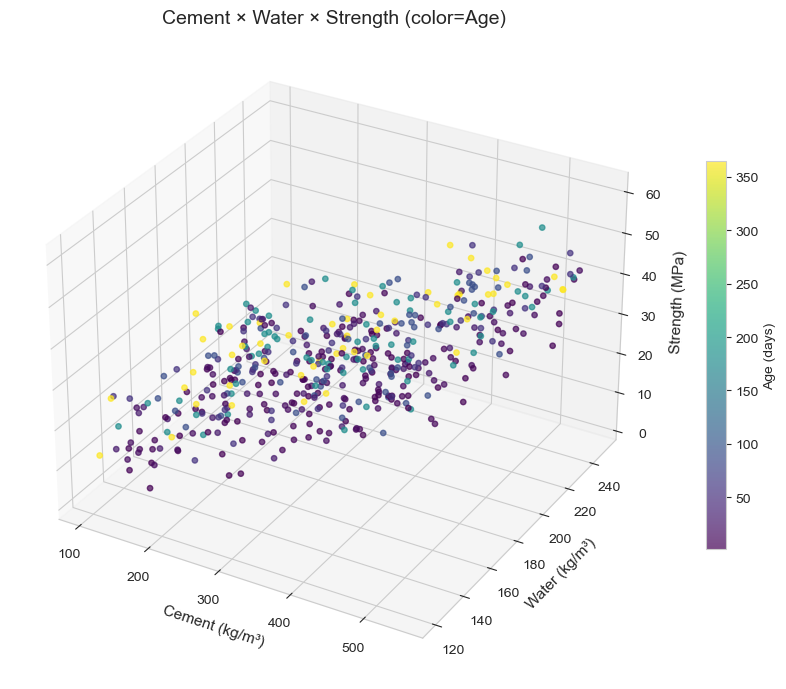

In [17]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['Cement'], df['Water'], df['Strength'],
               c=df['Age'], cmap='viridis', s=15, alpha=0.7)
ax.set_xlabel('Cement (kg/m³)', fontsize=11)
ax.set_ylabel('Water (kg/m³)', fontsize=11)
ax.set_zlabel('Strength (MPa)', fontsize=11)
ax.set_title('Cement × Water × Strength (color=Age)', fontsize=14)
plt.colorbar(sc, label='Age (days)', shrink=0.6)
plt.tight_layout(); plt.show()

---
#### **6 - Data Cleaning & Preprocessing**

##### **6.1 Handling Missing Values**

<font color='blue'>**Example) Strategies for handling missing values**</font>

In [18]:
df_clean = df.copy()
missing_before = df_clean.isnull().sum()
print('Missing values BEFORE:')
print(missing_before[missing_before > 0])
print()

# Strategy: Fill with column median (robust to outliers)
for col in ['Slag', 'Ash', 'Superplasticizer']:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f'{col}: filled with median = {median_val:.2f}')

print()
print('Missing values AFTER:')
print(df_clean.isnull().sum().sum(), 'total missing values')

Missing values BEFORE:
Slag                18
Ash                 27
Superplasticizer    30
dtype: int64

Slag: filled with median = 170.29
Ash: filled with median = 108.90
Superplasticizer: filled with median = 16.17

Missing values AFTER:
0 total missing values


##### **6.2 Log Transformation (for Skewed Data)**

<font color='blue'>**Example) Log-transform the Age column to reduce skewness**</font>

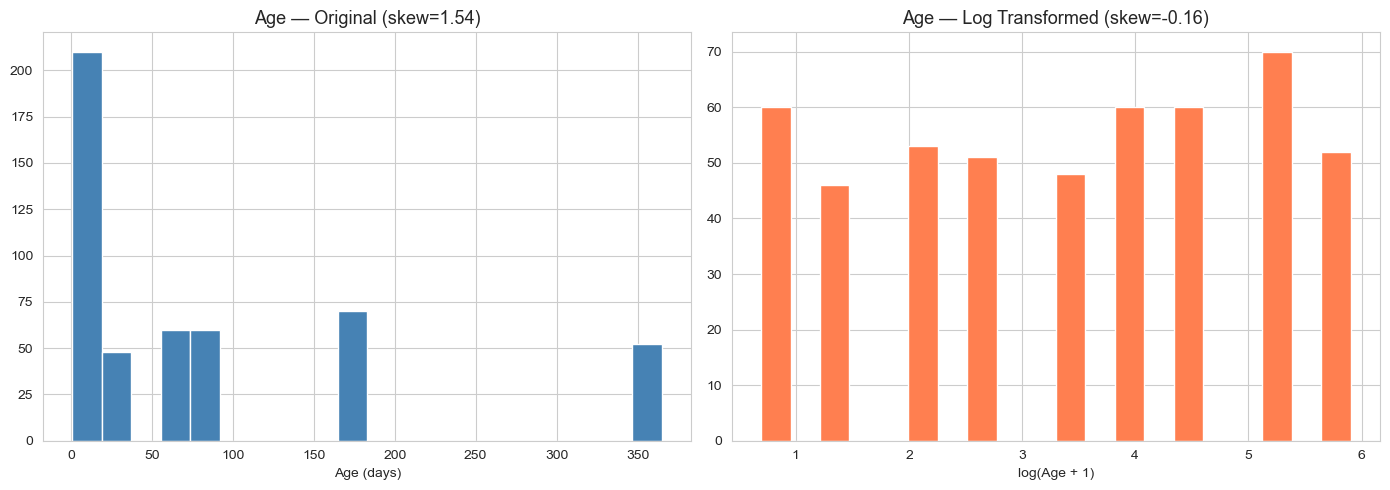

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(df_clean['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title(f'Age — Original (skew={df_clean["Age"].skew():.2f})', fontsize=13)
axes[0].set_xlabel('Age (days)')

# After log transform
df_clean['Age_log'] = np.log1p(df_clean['Age'])
axes[1].hist(df_clean['Age_log'], bins=20, color='coral', edgecolor='white')
axes[1].set_title(f'Age — Log Transformed (skew={df_clean["Age_log"].skew():.2f})', fontsize=13)
axes[1].set_xlabel('log(Age + 1)')

plt.tight_layout(); plt.show()

<font color='red'>**Exercise 6.1) Apply log transformation to the `Superplasticizer` column and compare before/after histograms.**</font>

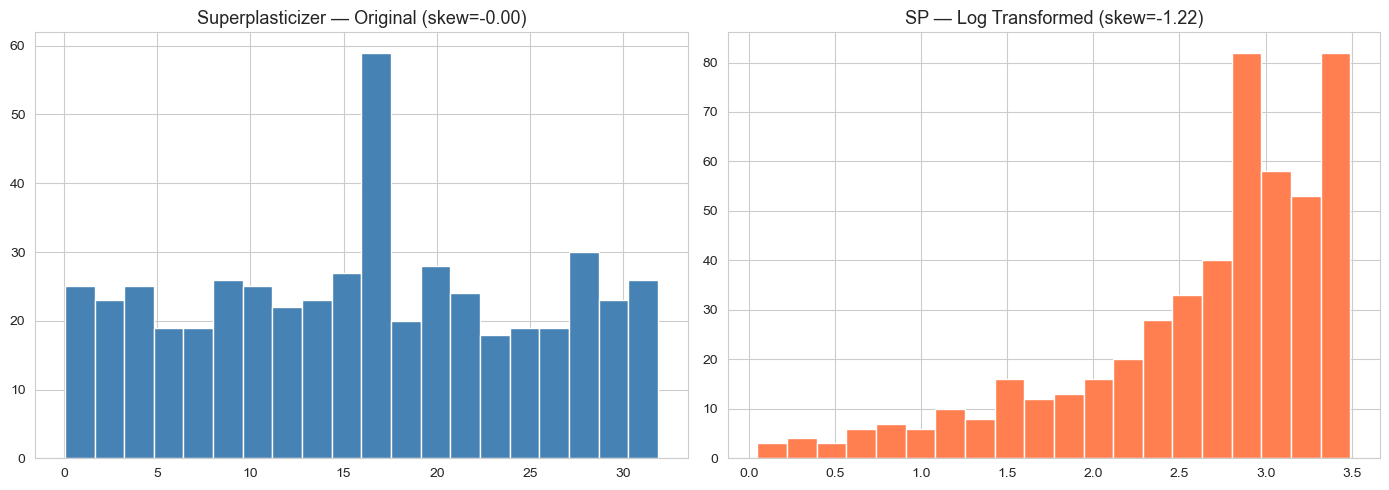

Skewness reduced from -0.00 to -1.22


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(df_clean['Superplasticizer'], bins=20, color='steelblue', edgecolor='white')
skew_before = df_clean['Superplasticizer'].skew()
axes[0].set_title(f'Superplasticizer — Original (skew={skew_before:.2f})', fontsize=13)

# After log transform
df_clean['SP_log'] = np.log1p(df_clean['Superplasticizer'])
skew_after = df_clean['SP_log'].skew()
axes[1].hist(df_clean['SP_log'], bins=20, color='coral', edgecolor='white')
axes[1].set_title(f'SP — Log Transformed (skew={skew_after:.2f})', fontsize=13)

plt.tight_layout(); plt.show()
print(f'Skewness reduced from {skew_before:.2f} to {skew_after:.2f}')

##### **6.3 Outlier Detection with IQR**

<font color='red'>**Exercise 6.2) Detect outliers in `Strength` using the IQR method and report how many.**</font>

Outlier rule: values below $Q_1 - 1.5 \times IQR$ or above $Q_3 + 1.5 \times IQR$.

In [26]:
Q1 = df_clean['Strength'].quantile(0.25)
Q3 = df_clean['Strength'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Strength'] < lower_bound) | (df_clean['Strength'] > upper_bound)]
print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')
print(f'Number of outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)')

Q1=19.01, Q3=37.78, IQR=18.78
Bounds: [-9.16, 65.95]
Number of outliers: 0 (0.0%)


---
#### **7 - Complete EDA Pipeline Summary**

<font color='red'>**Exercise 7.1) Perform a complete mini-EDA on the features `Cement` and `Strength`.**</font>

Complete all 5 steps below:

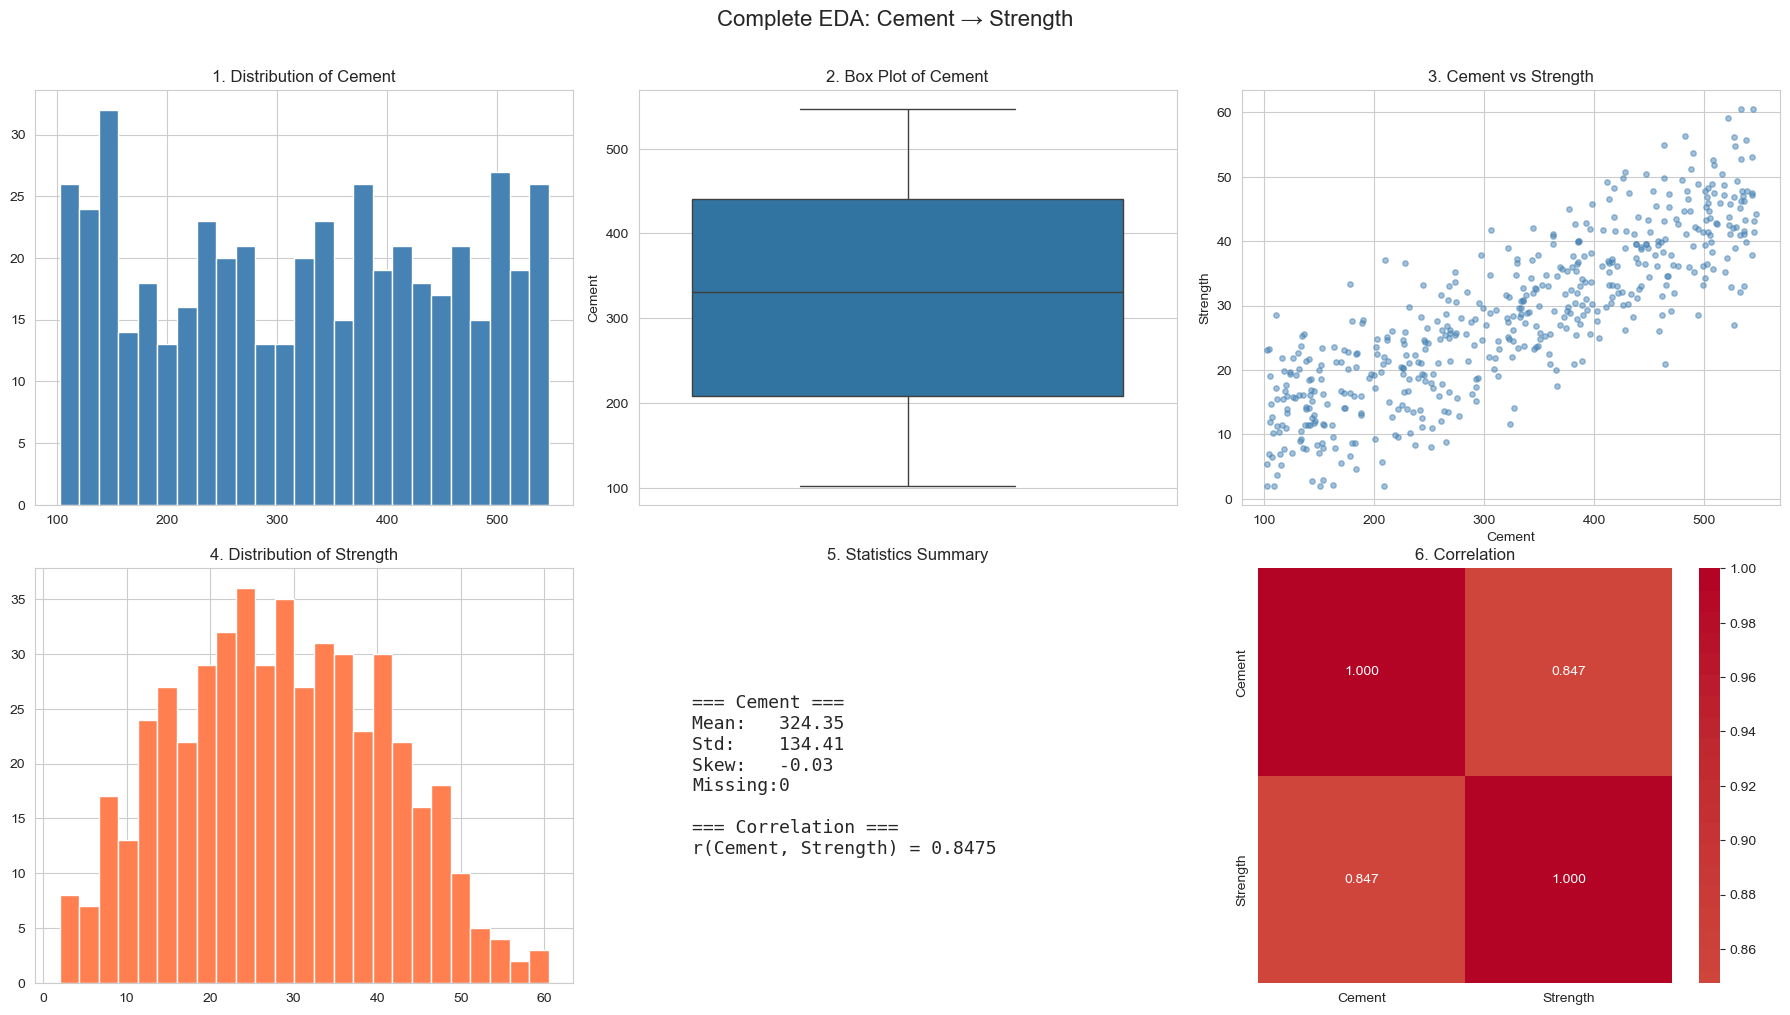

In [27]:
# === COMPLETE EDA PIPELINE ===

col = 'Cement'
target = 'Strength'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram of feature
axes[0,0].hist(df_clean[col], bins=25, color='steelblue', edgecolor='white')
axes[0,0].set_title(f'1. Distribution of {col}', fontsize=12)

# (2) Box plot of feature
sns.boxplot(y=df_clean[col], ax=axes[0,1])
axes[0,1].set_title(f'2. Box Plot of {col}', fontsize=12)

# (3) Scatter plot: feature vs target
axes[0,2].scatter(df_clean[col], df_clean[target],
                    s=15, alpha=0.5, color='steelblue')
axes[0,2].set_xlabel(col); axes[0,2].set_ylabel(target)
axes[0,2].set_title(f'3. {col} vs {target}', fontsize=12)

# (4) Histogram of target
axes[1,0].hist(df_clean[target], bins=25, color='coral', edgecolor='white')
axes[1,0].set_title(f'4. Distribution of {target}', fontsize=12)

# (5) Statistics summary
axes[1,1].axis('off')
stats_text = f"""
=== {col} ===
Mean:   {df_clean[col].mean():.2f}
Std:    {df_clean[col].std():.2f}
Skew:   {df_clean[col].skew():.2f}
Missing:{df_clean[col].isnull().sum()}

=== Correlation ===
r({col}, {target}) = {df_clean[col].corr(df_clean[target]):.4f}
"""
axes[1,1].text(0.1, 0.5, stats_text, fontsize=13, family='monospace',
              verticalalignment='center', transform=axes[1,1].transAxes)
axes[1,1].set_title('5. Statistics Summary', fontsize=12)

# (6) Empty — or correlation heatmap subset
subset = df_clean[[col, target]].corr()    # .corr()
sns.heatmap(subset, annot=True, fmt='.3f', cmap='coolwarm',
           ax=axes[1,2], center=0, square=True)
axes[1,2].set_title('6. Correlation', fontsize=12)

plt.suptitle(f'Complete EDA: {col} → {target}', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

---
##### **Further Reading**
- [The Fundamentals of EDA — Analytics Vidhya](https://www.analyticsvidhya.com/blog/2021/11/fundamentals-of-exploratory-data-analysis/)
- [Step-by-Step EDA using Python](https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda/)
- [Two Handy Alternatives to Pandas describe()](https://blog.dailydoseofds.com/) — Skimpy, SummaryTools
- [Automated EDA Tool Stack](https://blog.dailydoseofds.com/) — sweetviz, ydata-profiling
- [Most Important Plots in Data Science](https://blog.dailydoseofds.com/)

---
**📌 Submission**: Complete all exercises → `Restart Kernel and Run All` → Save (`Ctrl+S`) → Submit via e-campus.